# Credit Risk Assessment & Default Prediction Framework (LendingClub)

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_sample = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=5)

In [3]:
df_sample

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
for i, col in enumerate(df_sample.columns):
    print(f"  {i+1:02d}. {col}")

  01. id
  02. member_id
  03. loan_amnt
  04. funded_amnt
  05. funded_amnt_inv
  06. term
  07. int_rate
  08. installment
  09. grade
  10. sub_grade
  11. emp_title
  12. emp_length
  13. home_ownership
  14. annual_inc
  15. verification_status
  16. issue_d
  17. loan_status
  18. pymnt_plan
  19. url
  20. desc
  21. purpose
  22. title
  23. zip_code
  24. addr_state
  25. dti
  26. delinq_2yrs
  27. earliest_cr_line
  28. fico_range_low
  29. fico_range_high
  30. inq_last_6mths
  31. mths_since_last_delinq
  32. mths_since_last_record
  33. open_acc
  34. pub_rec
  35. revol_bal
  36. revol_util
  37. total_acc
  38. initial_list_status
  39. out_prncp
  40. out_prncp_inv
  41. total_pymnt
  42. total_pymnt_inv
  43. total_rec_prncp
  44. total_rec_int
  45. total_rec_late_fee
  46. recoveries
  47. collection_recovery_fee
  48. last_pymnt_d
  49. last_pymnt_amnt
  50. next_pymnt_d
  51. last_credit_pull_d
  52. last_fico_range_high
  53. last_fico_range_low
  54. collections

In [5]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [7]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [8]:
default_map = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
}

In [9]:
df = df[df['loan_status'].isin(default_map.keys())].copy()
df['target'] = df['loan_status'].map(default_map)

In [10]:
df.target.value_counts()

target
0    1078739
1     295176
Name: count, dtype: int64

In [11]:
df['target'].mean()

np.float64(0.21484298519195147)

In [12]:
# Columns to DROP
drop_cols = [
    # Identifiers
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
    
    # Post-disbursement leakage — the most critical drops
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_fico_range_high',
    'last_fico_range_low', 'last_credit_pull_d',
    
    # Hardship & settlement (post-default, Module 3 territory)
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    
    # Near-zero variance / useless
    'pymnt_plan', 'policy_code', 'emp_title', 'disbursement_method',
    
    # Joint application (2-3% of data, handle separately later)
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
    'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',
    
    # Original target — replaced by engineered 'target'
    'loan_status'
]


In [13]:
df.drop(columns=drop_cols, inplace=True)

In [14]:
df.shape[1]

88

In [15]:
for i, col in enumerate(df.columns):
    print(f"  {i+1:02d}. {col}")

  01. loan_amnt
  02. funded_amnt
  03. funded_amnt_inv
  04. term
  05. int_rate
  06. installment
  07. grade
  08. sub_grade
  09. emp_length
  10. home_ownership
  11. annual_inc
  12. verification_status
  13. issue_d
  14. purpose
  15. addr_state
  16. dti
  17. delinq_2yrs
  18. earliest_cr_line
  19. fico_range_low
  20. fico_range_high
  21. inq_last_6mths
  22. mths_since_last_delinq
  23. mths_since_last_record
  24. open_acc
  25. pub_rec
  26. revol_bal
  27. revol_util
  28. total_acc
  29. initial_list_status
  30. collections_12_mths_ex_med
  31. mths_since_last_major_derog
  32. application_type
  33. acc_now_delinq
  34. tot_coll_amt
  35. tot_cur_bal
  36. open_acc_6m
  37. open_act_il
  38. open_il_12m
  39. open_il_24m
  40. mths_since_rcnt_il
  41. total_bal_il
  42. il_util
  43. open_rv_12m
  44. open_rv_24m
  45. max_bal_bc
  46. all_util
  47. total_rev_hi_lim
  48. inq_fi
  49. total_cu_tl
  50. inq_last_12m
  51. acc_open_past_24mths
  52. avg_cur_bal
  53.

In [16]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,target
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,0
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,0
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,0


In [17]:
df.term.value_counts()

term
36 months    1038225
60 months     335690
Name: count, dtype: int64

In [18]:
df.sub_grade.unique()

array(['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2',
       'A4', 'E3', 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5',
       'F2', 'E4', 'D2', 'E1', 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4',
       'F4', 'G5'], dtype=object)

In [19]:
df.shape

(1373915, 88)

In [20]:
# 1. Average FICO score
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

In [21]:
# 2. Credit history length in years
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['credit_history_years'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
).round(1)


In [22]:
drop_pass2 = [
    # Redundant
    'funded_amnt', 'funded_amnt_inv',
    'fico_range_low', 'fico_range_high',
    'grade',
    'issue_d', 'earliest_cr_line',
    'initial_list_status', 'application_type',
    
    # Sparse post-2012 columns
    'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq',
    'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'tot_hi_cred_lim', 'total_bc_limit', 'total_il_high_credit_limit'
]

df.drop(columns=drop_pass2, inplace=True)

In [23]:
for i, col in enumerate(df.columns):
    print(f"  {i+1:02d}. {col}")

  01. loan_amnt
  02. term
  03. int_rate
  04. installment
  05. sub_grade
  06. emp_length
  07. home_ownership
  08. annual_inc
  09. verification_status
  10. purpose
  11. addr_state
  12. dti
  13. delinq_2yrs
  14. inq_last_6mths
  15. mths_since_last_delinq
  16. mths_since_last_record
  17. open_acc
  18. pub_rec
  19. revol_bal
  20. revol_util
  21. total_acc
  22. collections_12_mths_ex_med
  23. mths_since_last_major_derog
  24. acc_now_delinq
  25. tot_coll_amt
  26. tot_cur_bal
  27. total_rev_hi_lim
  28. acc_open_past_24mths
  29. avg_cur_bal
  30. bc_open_to_buy
  31. bc_util
  32. chargeoff_within_12_mths
  33. delinq_amnt
  34. mort_acc
  35. mths_since_recent_inq
  36. num_accts_ever_120_pd
  37. num_actv_bc_tl
  38. num_actv_rev_tl
  39. num_bc_sats
  40. num_bc_tl
  41. num_il_tl
  42. num_op_rev_tl
  43. num_rev_accts
  44. num_rev_tl_bal_gt_0
  45. num_sats
  46. num_tl_op_past_12m
  47. pct_tl_nvr_dlq
  48. percent_bc_gt_75
  49. pub_rec_bankruptcies
  50. tax

In [24]:
df.sort_values(by = "loan_amnt", ascending=False)

,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,num_sats,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,total_bal_ex_mort,target,fico_avg,credit_history_years
2260680,40000.0,60 months,15.59,964.03,C5,< 1 year,MORTGAGE,220000.0,Verified,debt_consolidation,...,19.0,3.0,100.0,0.0,0.0,0.0,73480.0,0,717.0,12.7
1940432,40000.0,60 months,17.99,1015.52,D2,10+ years,MORTGAGE,240000.0,Verified,home_improvement,...,12.0,5.0,93.8,0.0,0.0,0.0,259087.0,0,757.0,31.2
1522659,40000.0,60 months,12.13,892.41,B5,9 years,RENT,58500.0,Source Verified,small_business,...,6.0,0.0,100.0,0.0,0.0,0.0,98.0,0,817.0,15.9
1522600,40000.0,60 months,15.49,961.92,C4,3 years,MORTGAGE,160000.0,Verified,home_improvement,...,5.0,2.0,67.9,100.0,0.0,0.0,226455.0,0,667.0,15.9
1002191,40000.0,36 months,14.46,1376.06,C4,5 years,MORTGAGE,450000.0,Verified,debt_consolidation,...,19.0,5.0,90.3,0.0,0.0,0.0,564712.0,0,732.0,32.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1653584,500.0,36 months,8.32,15.75,A4,1 year,OTHER,100000.0,Not Verified,medical,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,747.0,2.8
1651492,500.0,36 months,8.07,15.69,A4,< 1 year,RENT,18000.0,Not Verified,other,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,722.0,4.0
1654200,500.0,36 months,12.49,16.73,D3,1 year,RENT,18000.0,Not Verified,credit_card,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0,657.0,14.1
1650811,500.0,36 months,9.76,16.08,B2,7 years,MORTGAGE,59000.0,Not Verified,other,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,742.0,12.6


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1373915 entries, 0 to 2260697
Data columns (total 54 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   loan_amnt                    1373915 non-null  float64
 1   term                         1373915 non-null  object 
 2   int_rate                     1373915 non-null  float64
 3   installment                  1373915 non-null  float64
 4   sub_grade                    1373915 non-null  object 
 5   emp_length                   1293065 non-null  object 
 6   home_ownership               1373915 non-null  object 
 7   annual_inc                   1373911 non-null  float64
 8   verification_status          1373915 non-null  object 
 9   purpose                      1373915 non-null  object 
 10  addr_state                   1373915 non-null  object 
 11  dti                          1373512 non-null  float64
 12  delinq_2yrs                  1373886 non-null  

In [26]:
missing = df.isnull().sum()

In [27]:
missing_pct = (missing / len(df) * 100).round(2)

In [28]:
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

In [29]:
missing_df

,missing_count,missing_pct
mths_since_last_record,1139727,82.95
mths_since_last_major_derog,1012276,73.68
mths_since_last_delinq,692066,50.37
mths_since_recent_inq,178971,13.03
emp_length,80850,5.88
pct_tl_nvr_dlq,70430,5.13
tot_cur_bal,70276,5.12
tot_coll_amt,70276,5.12
num_accts_ever_120_pd,70276,5.12
avg_cur_bal,70299,5.12


In [30]:
sentinel_cols = [
    'mths_since_last_record',
    'mths_since_last_major_derog', 
    'mths_since_last_delinq',
    'mths_since_recent_inq'
]
df[sentinel_cols] = df[sentinel_cols].fillna(999)

In [31]:
zero_fill_cols = [
    'pub_rec_bankruptcies', 'tax_liens',
    'collections_12_mths_ex_med', 'chargeoff_within_12_mths',
    'acc_now_delinq', 'delinq_amnt'
]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

In [32]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [33]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

In [34]:
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

In [35]:
remaining_missing = df.isnull().sum()

In [36]:
remaining_missing

loan_amnt                      0
term                           0
int_rate                       0
installment                    0
sub_grade                      0
emp_length                     0
home_ownership                 0
annual_inc                     0
verification_status            0
purpose                        0
addr_state                     0
dti                            0
delinq_2yrs                    0
inq_last_6mths                 0
mths_since_last_delinq         0
mths_since_last_record         0
open_acc                       0
pub_rec                        0
revol_bal                      0
revol_util                     0
total_acc                      0
collections_12_mths_ex_med     0
mths_since_last_major_derog    0
acc_now_delinq                 0
tot_coll_amt                   0
tot_cur_bal                    0
total_rev_hi_lim               0
acc_open_past_24mths           0
avg_cur_bal                    0
bc_open_to_buy                 0
bc_util   

In [37]:
remaining_missing.sum()

np.int64(0)

In [38]:
df.shape

(1373915, 54)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1373915 entries, 0 to 2260697
Data columns (total 54 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   loan_amnt                    1373915 non-null  float64
 1   term                         1373915 non-null  object 
 2   int_rate                     1373915 non-null  float64
 3   installment                  1373915 non-null  float64
 4   sub_grade                    1373915 non-null  object 
 5   emp_length                   1373915 non-null  object 
 6   home_ownership               1373915 non-null  object 
 7   annual_inc                   1373915 non-null  float64
 8   verification_status          1373915 non-null  object 
 9   purpose                      1373915 non-null  object 
 10  addr_state                   1373915 non-null  object 
 11  dti                          1373915 non-null  float64
 12  delinq_2yrs                  1373915 non-null  

In [40]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [41]:
cat_cols

['term',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state']

In [42]:
df.term.value_counts()

term
36 months    1038225
60 months     335690
Name: count, dtype: int64

In [43]:
df.sub_grade.value_counts()

sub_grade
C1    87266
B4    84609
B5    84238
B3    82948
C2    80990
C3    76869
C4    76557
B2    75014
B1    72074
C5    69671
A5    64562
D1    52748
A4    52684
D2    46157
A1    43869
D3    40696
A3    38310
A2    37431
D4    36752
D5    31034
E1    24383
E2    21990
E3    19056
E4    16261
E5    15070
F1    10269
F2     7401
F3     6282
F4     5019
F5     4104
G1     3127
G2     2207
G3     1685
G4     1368
G5     1214
Name: count, dtype: int64

In [44]:
df.emp_length.value_counts()

emp_length
10+ years    450538
2 years      124452
< 1 year     110993
3 years      110004
1 year        90572
5 years       85921
4 years       82430
Unknown       80850
6 years       63998
8 years       61728
7 years       60646
9 years       51783
Name: count, dtype: int64

In [45]:
df.home_ownership.value_counts()

home_ownership
MORTGAGE    678091
RENT        547026
OWN         148258
ANY            305
OTHER          182
NONE            53
Name: count, dtype: int64

In [46]:
df.purpose.value_counts()

purpose
debt_consolidation    796439
credit_card           300459
home_improvement       89487
other                  80215
major_purchase         30225
small_business         15987
medical                15957
car                    14874
moving                  9747
vacation                9271
house                   7527
wedding                 2350
renewable_energy         954
educational              423
Name: count, dtype: int64

In [47]:
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().head(6))


term (2 unique):
term
36 months    1038225
60 months     335690
Name: count, dtype: int64

sub_grade (35 unique):
sub_grade
C1    87266
B4    84609
B5    84238
B3    82948
C2    80990
C3    76869
Name: count, dtype: int64

emp_length (12 unique):
emp_length
10+ years    450538
2 years      124452
< 1 year     110993
3 years      110004
1 year        90572
5 years       85921
Name: count, dtype: int64

home_ownership (6 unique):
home_ownership
MORTGAGE    678091
RENT        547026
OWN         148258
ANY            305
OTHER          182
NONE            53
Name: count, dtype: int64

verification_status (3 unique):
verification_status
Source Verified    532457
Verified           427001
Not Verified       414457
Name: count, dtype: int64

purpose (14 unique):
purpose
debt_consolidation    796439
credit_card           300459
home_improvement       89487
other                  80215
major_purchase         30225
small_business         15987
Name: count, dtype: int64

addr_state (51 unique):


In [ ]:
# ── term — binary encode 
df['term'] = df['term'].str.strip().map({'36 months': 0, '60 months': 1})

In [49]:
# sub_grade — ordinal encode 
grades = ['A1','A2','A3','A4','A5',
          'B1','B2','B3','B4','B5',
          'C1','C2','C3','C4','C5',
          'D1','D2','D3','D4','D5',
          'E1','E2','E3','E4','E5',
          'F1','F2','F3','F4','F5',
          'G1','G2','G3','G4','G5']
grade_map = {g: i+1 for i, g in enumerate(grades)}
df['sub_grade'] = df['sub_grade'].map(grade_map)

In [50]:
# emp_length — ordinal encode
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2,
    '3 years': 3,  '4 years': 4, '5 years': 5,
    '6 years': 6,  '7 years': 7, '8 years': 8,
    '9 years': 9,  '10+ years': 10, 'Unknown': -1
}
df['emp_length'] = df['emp_length'].map(emp_map)

In [51]:
df['home_ownership'] = df['home_ownership'].replace(
    ['ANY', 'NONE', 'OTHER'], 'OTHER'
)
home_map = {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3}
df['home_ownership'] = df['home_ownership'].map(home_map)

In [52]:
verif_map = {
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
}
df['verification_status'] = df['verification_status'].map(verif_map)

In [53]:
purpose_map = {p: i for i, p in 
               enumerate(df['purpose'].value_counts().index)}
df['purpose'] = df['purpose'].map(purpose_map)

In [54]:
state_default_rate = df.groupby('addr_state')['target'].mean()
df['addr_state'] = df['addr_state'].map(state_default_rate)

In [ ]:
cat_remaining = df.select_dtypes(include='object').columns.tolist()
print(f"Remaining categorical columns: {cat_remaining}")
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

Remaining categorical columns: []

Shape: (1373915, 54)

Data types:
float64    47
int64       7
Name: count, dtype: int64

Sample encoded values:
   term  sub_grade  emp_length  home_ownership  verification_status  purpose  \
0     0         14          10               2                    0        0   
1     0         11          10               2                    0        5   
2     1          9          10               2                    0        2   
4     1         26           3               2                    1        4   
5     0         13           4               0                    1        0   

   addr_state  
0    0.223201  
1    0.225657  
2    0.194328  
4    0.223201  
5    0.199445  


In [56]:
df[['term', 'sub_grade', 'emp_length', 
          'home_ownership', 'verification_status',
          'purpose', 'addr_state']].head()

,term,sub_grade,emp_length,home_ownership,verification_status,purpose,addr_state
0,0,14,10,2,0,0,0.223201
1,0,11,10,2,0,5,0.225657
2,1,9,10,2,0,2,0.194328
4,1,26,3,2,1,4,0.223201
5,0,13,4,0,1,0,0.199445


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

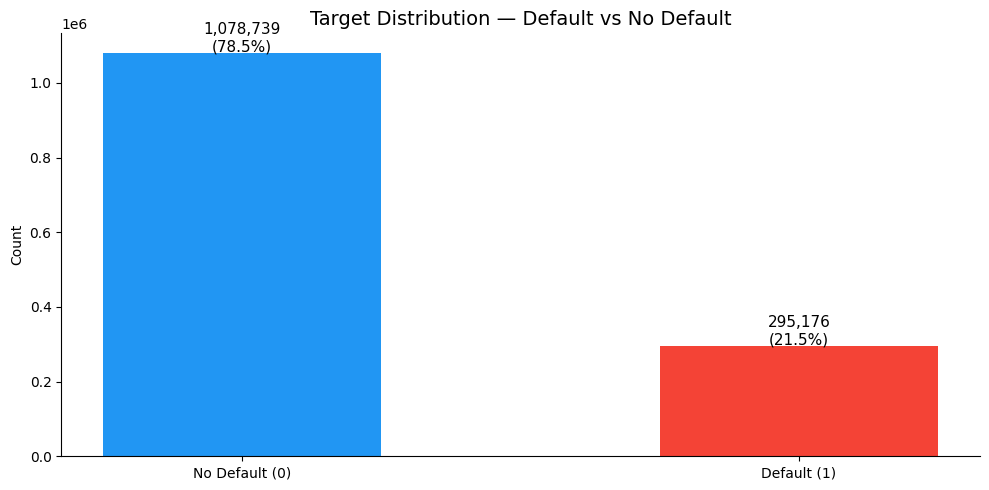

In [60]:
fig, ax = plt.subplots()
counts = df['target'].value_counts()
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
              color=['#2196F3', '#F44336'], width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', fontsize=11)
ax.set_title('Target Distribution — Default vs No Default', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_1_target_distribution.png', dpi=150)
plt.show()

In [61]:
df['fico_bin'] = pd.cut(df['fico_avg'],
    bins=[580, 620, 640, 660, 680, 700, 720, 740, 760, 800, 850],
    labels=['580-620','620-640','640-660','660-680',
            '680-700','700-720','720-740','740-760','760-800','800-850'])

fico_default = df.groupby('fico_bin')['target'].mean() * 100


In [62]:
fico_default

fico_bin
580-620    33.333333
620-640    50.000000
640-660    30.296610
660-680    26.846909
680-700    22.967753
700-720    18.797169
720-740    15.254025
740-760    12.565159
760-800    10.012020
800-850     7.601405
Name: target, dtype: float64

In [64]:
# ── ANALYSIS 2 — FICO vs Default Rate

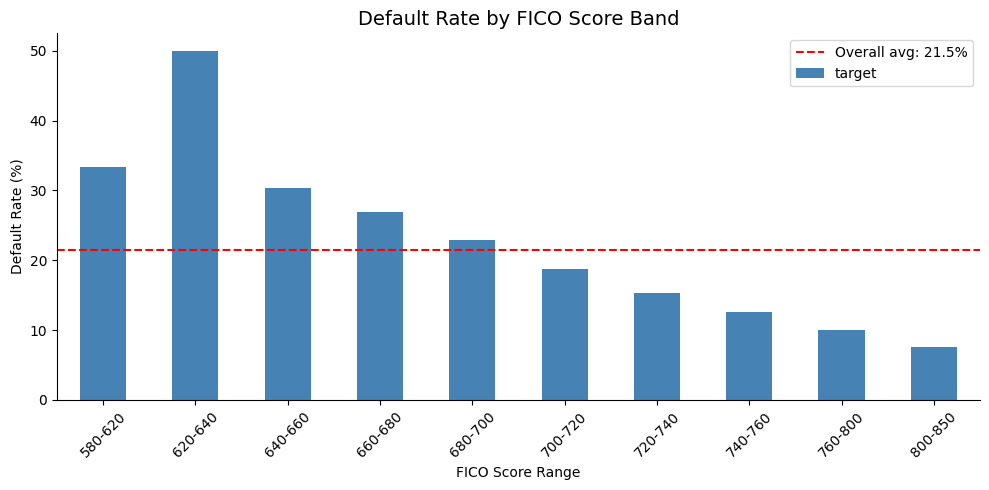

In [65]:
fig, ax = plt.subplots()
fico_default.plot(kind='bar', color='steelblue', ax=ax, rot=45)
ax.set_title('Default Rate by FICO Score Band', fontsize=14)
ax.set_xlabel('FICO Score Range')
ax.set_ylabel('Default Rate (%)')
ax.axhline(df['target'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["target"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('eda_2_fico_default_rate.png', dpi=150)
plt.show()

In [66]:
#  ANALYSIS 3 — DTI vs Default Rate

In [67]:
df_dti = df[df['dti'] <= 40].copy()  # remove extreme outliers
df_dti['dti_bin'] = pd.cut(df_dti['dti'],
    bins=[0,5,10,15,20,25,30,35,40],
    labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40'])

dti_default = df_dti.groupby('dti_bin')['target'].mean() * 100

In [68]:
dti_default

dti_bin
0-5      16.519238
5-10     16.402017
10-15    17.990226
15-20    20.434248
20-25    23.207377
25-30    26.458928
30-35    30.189982
35-40    32.826538
Name: target, dtype: float64

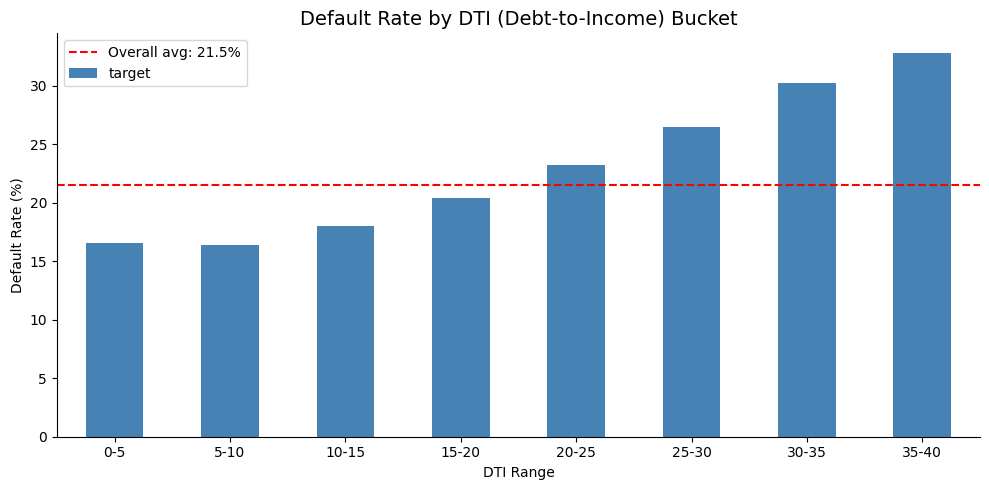

In [69]:
fig, ax = plt.subplots()
dti_default.plot(kind='bar', color='steelblue', ax=ax, rot=0)
ax.set_title('Default Rate by DTI (Debt-to-Income) Bucket', fontsize=14)
ax.set_xlabel('DTI Range')
ax.set_ylabel('Default Rate (%)')
ax.axhline(df['target'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["target"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('eda_3_dti_default_rate.png', dpi=150)
plt.show()

In [70]:
# ── ANALYSIS 4 — Revolving Utilization vs Default Rate

In [71]:
df_util = df[df['revol_util'] <= 100].copy()
df_util['util_bin'] = pd.cut(df_util['revol_util'],
    bins=[0,10,20,30,40,50,60,70,80,90,100],
    labels=['0-10','10-20','20-30','30-40','40-50',
            '50-60','60-70','70-80','80-90','90-100'])

util_default = df_util.groupby('util_bin')['target'].mean() * 100

In [72]:
util_default

util_bin
0-10      16.416581
10-20     16.937510
20-30     18.795933
30-40     20.346601
40-50     21.486070
50-60     22.493033
60-70     23.041444
70-80     23.341882
80-90     23.648712
90-100    24.487896
Name: target, dtype: float64

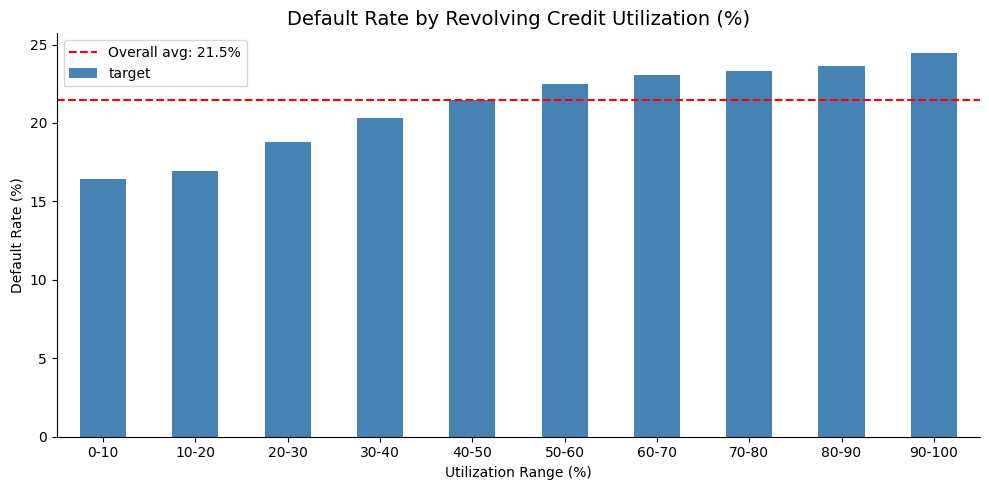

In [73]:
fig, ax = plt.subplots()
util_default.plot(kind='bar', color='steelblue', ax=ax, rot=0)
ax.set_title('Default Rate by Revolving Credit Utilization (%)', fontsize=14)
ax.set_xlabel('Utilization Range (%)')
ax.set_ylabel('Default Rate (%)')
ax.axhline(df['target'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["target"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('eda_4_revol_util_default_rate.png', dpi=150)
plt.show()

In [74]:
# ── ANALYSIS 5 — Default Rate by Purpose

In [75]:
purpose_labels = {i: p for i, p in 
                  enumerate(df['purpose'].value_counts(
                  ).index.tolist())}

# Compute default rate per purpose code
purpose_default = df.groupby('purpose')['target'].mean() * 100
purpose_default.index = [purpose_labels.get(i, i) 
                         for i in purpose_default.index]
purpose_default = purpose_default.sort_values(ascending=True)

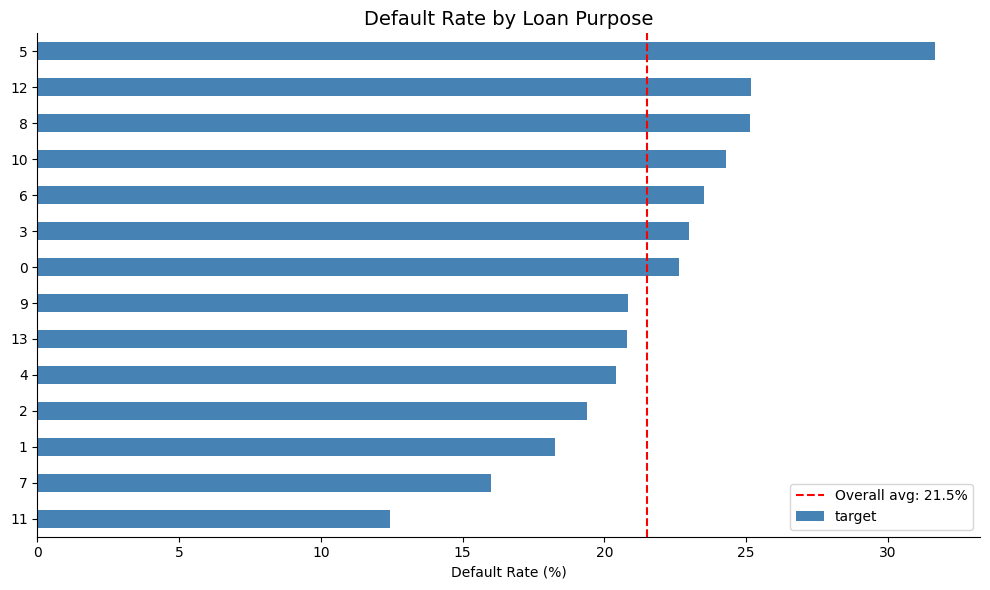

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))
purpose_default.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Default Rate by Loan Purpose', fontsize=14)
ax.set_xlabel('Default Rate (%)')
ax.axvline(df['target'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["target"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('eda_5_purpose_default_rate.png', dpi=150)
plt.show()

In [77]:
purpose_default

11    12.425532
7     15.994353
1     18.269048
2     19.379351
4     20.423490
13    20.803783
9     20.828390
0     22.641282
3     22.965779
6     23.525725
10    24.285904
8     25.135939
12    25.157233
5     31.663226
Name: target, dtype: float64

In [78]:
# ── ANALYSIS 6 — Correlation Heatmap (top features only)

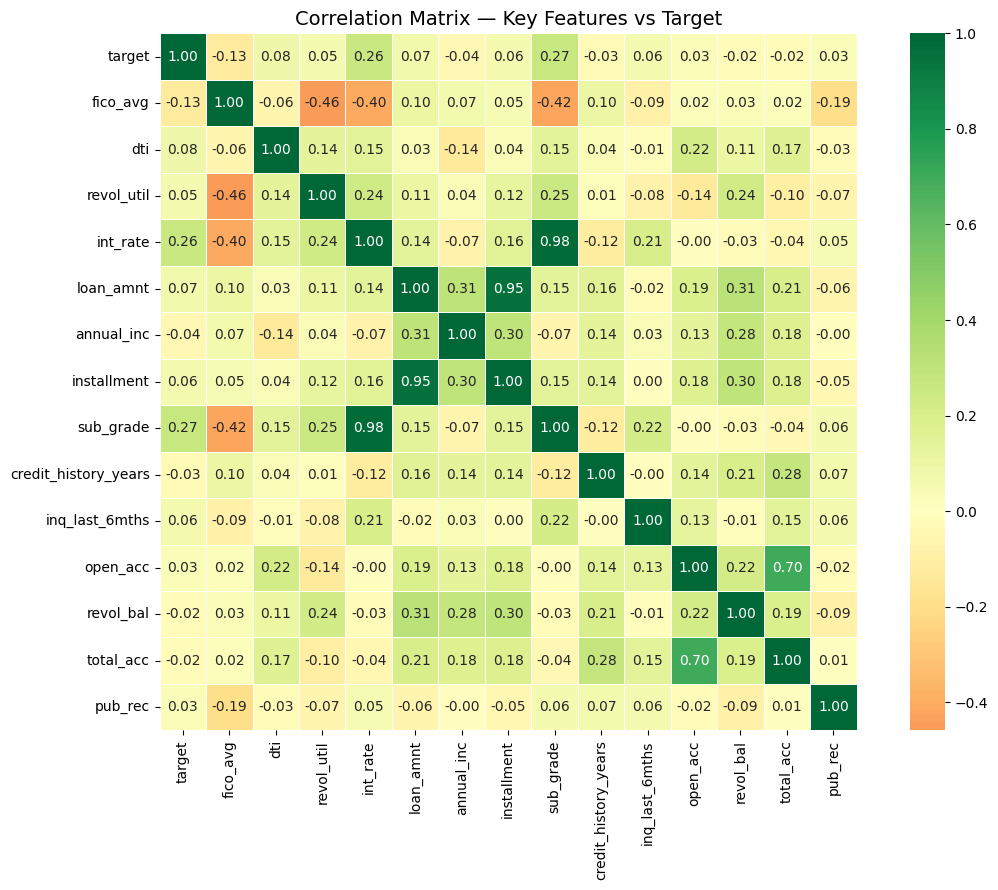

In [79]:
top_features = ['target', 'fico_avg', 'dti', 'revol_util', 'int_rate',
                'loan_amnt', 'annual_inc', 'installment', 'sub_grade',
                'credit_history_years', 'inq_last_6mths', 'open_acc',
                'revol_bal', 'total_acc', 'pub_rec']

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Features vs Target', fontsize=14)
plt.tight_layout()
plt.savefig('eda_6_correlation_heatmap.png', dpi=150)
plt.show()

In [80]:
# ── ANALYSIS 7 — Default Rate by Sub-grade

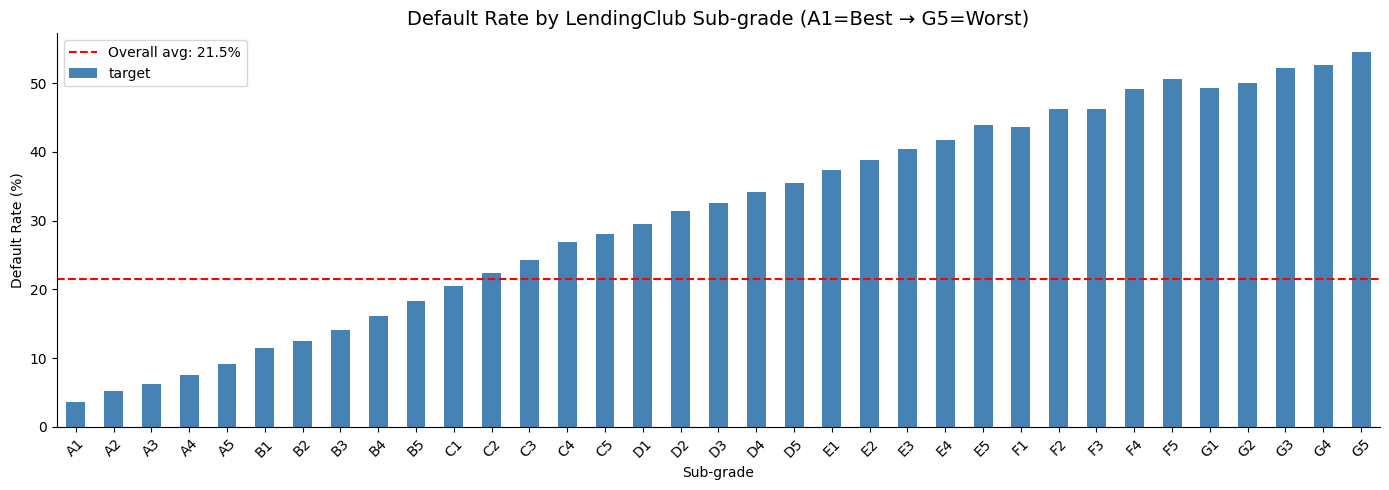

In [81]:
subgrade_default = df.groupby('sub_grade')['target'].mean() * 100
subgrade_default.index = grades[:len(subgrade_default)]

fig, ax = plt.subplots(figsize=(14, 5))
subgrade_default.plot(kind='bar', color='steelblue', ax=ax, rot=45)
ax.set_title("Default Rate by LendingClub Sub-grade (A1=Best → G5=Worst)",
             fontsize=14)
ax.set_xlabel('Sub-grade')
ax.set_ylabel('Default Rate (%)')
ax.axhline(df['target'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["target"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('eda_7_subgrade_default_rate.png', dpi=150)
plt.show()

In [82]:
import numpy as np

In [83]:
# ── STEP 1: Ratio & Capacity Features ─────────────────────────
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['payment_to_income'] = (df['installment'] * 12) / (df['annual_inc'] + 1)  # Annual EMI ratio
df['revol_bal_ratio'] = df['revol_bal'] / (df['total_rev_hi_lim'] + 1)
df['bc_util_norm'] = df['bc_util'] / 100
df['acc_utilization'] = df['open_acc'] / (df['total_acc'] + 1)

In [84]:
# ── STEP 2: FICO Band Features (STRONGEST SIGNAL) ─────────────
# Based on EDA: 620-640 = 50% default, 800+ = 7.5% default
def fico_band(fico):
    if fico < 640:
        return 0  # Very High Risk
    elif fico < 680:
        return 1  # High Risk
    elif fico < 720:
        return 2  # Medium Risk
    elif fico < 760:
        return 3  # Low Risk
    else:
        return 4  # Very Low Risk

In [85]:
df['fico_band'] = df['fico_avg'].apply(fico_band)

In [86]:
# Binary flags for extreme bands
df['is_very_low_fico'] = (df['fico_avg'] < 640).astype(int)  # 50% default zone
df['is_very_high_fico'] = (df['fico_avg'] >= 760).astype(int)  # 10% default zone

In [87]:
# ── STEP 3: DTI Danger Zone Flag ──────────────────────────────
# EDA showed DTI >30% = 30-33% default (vs 16% for DTI <10%)
df['is_high_dti'] = (df['dti'] > 30).astype(int)
df['dti_severe'] = (df['dti'] > 35).astype(int)  # 33% default zone

In [88]:
# ── STEP 4: Interaction Features (Compound Risk) ──────────────
df['dti_x_intrate'] = df['dti'] * df['int_rate']  # Keep this for now
df['grade_x_util'] = df['sub_grade'] * df['revol_util']  # Strong combo
df['fico_x_dti'] = df['fico_avg'] * df['dti']  # NEW: FICO and DTI interaction
df['loan_x_history'] = df['loan_amnt'] / (df['credit_history_years'] + 1)

In [89]:
# ── STEP 5: Sub-grade Risk Flags ──────────────────────────────
# EDA: A1-A3 = 4-7% default, G3-G5 = 50-55% default
df['is_prime_grade'] = (df['sub_grade'] <= 3).astype(int)  # A1-A3
df['is_subprime_grade'] = (df['sub_grade'] >= 33).astype(int)  # G3-G5

In [90]:
# ── STEP 6: Log Transform ─────────────────────────────────────
df['log_annual_inc'] = np.log1p(df['annual_inc'])
df['log_loan_amnt'] = np.log1p(df['loan_amnt'])

In [91]:
# ── STEP 7: Binary Delinquency Flags ─────────────────────────
df['has_delinquency'] = (df['delinq_2yrs'] > 0).astype(int)
df['has_bankruptcy'] = (df['pub_rec_bankruptcies'] > 0).astype(int)
df['has_collection'] = (df['collections_12_mths_ex_med'] > 0).astype(int)
df['is_high_util'] = (df['revol_util'] > 75).astype(int)

In [92]:
# ── STEP 8: Purpose Risk Mapping (UPDATED from EDA) ──────────
# Based on actual default rates from Chart 5
purpose_risk_map = {
    0: 3,   # debt_consolidation → ~22% (medium)
    1: 2,   # credit_card → ~18% (low-medium)
    2: 2,   # home_improvement → ~19% (low-medium)
    3: 4,   # other → ~23% (high)
    4: 4,   # major_purchase → ~20% (medium-high)
    5: 5,   # small_business → ~32% (HIGHEST)
    6: 3,   # educational → ~22% (medium)
    7: 2,   # wedding → ~16% (low)
    8: 3,   # moving → ~22% (medium)
    9: 4,   # house → ~24% (high)
    10: 2,  # car → ~19% (low-medium, collateralized)
    11: 1,  # medical → ~20% (low-medium, emergency)
    12: 3,  # vacation → ~21% (medium)
    13: 1   # renewable_energy → ~12.5% (LOWEST)
}
df['purpose_risk_score'] = df['purpose'].map(purpose_risk_map)

In [93]:
# ── STEP 9: Drop HIGHLY CORRELATED Features ──────────────────
# Based on correlation heatmap
drop_cols = [
    'int_rate',          # 0.98 corr with sub_grade (DROP)
    'installment',       # 0.95 corr with loan_amnt (DROP)
    'total_rev_hi_lim',  # Used in revol_bal_ratio
    'annual_inc',        # Replaced by log + ratios
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [94]:
print(f"   Final shape: {df.shape}")
print(f"   Features: {df.shape[1]-1} (excluding target)")

   Final shape: (1373915, 74)
   Features: 73 (excluding target)


In [95]:
new_feats = [c for c in df.columns if c not in ['target']]
print(f"\n📋 Final feature list ({len(new_feats)}):")
for i, f in enumerate(new_feats, 1):
    print(f"   {i:02d}. {f}")



📋 Final feature list (73):
   01. loan_amnt
   02. term
   03. sub_grade
   04. emp_length
   05. home_ownership
   06. verification_status
   07. purpose
   08. addr_state
   09. dti
   10. delinq_2yrs
   11. inq_last_6mths
   12. mths_since_last_delinq
   13. mths_since_last_record
   14. open_acc
   15. pub_rec
   16. revol_bal
   17. revol_util
   18. total_acc
   19. collections_12_mths_ex_med
   20. mths_since_last_major_derog
   21. acc_now_delinq
   22. tot_coll_amt
   23. tot_cur_bal
   24. acc_open_past_24mths
   25. avg_cur_bal
   26. bc_open_to_buy
   27. bc_util
   28. chargeoff_within_12_mths
   29. delinq_amnt
   30. mort_acc
   31. mths_since_recent_inq
   32. num_accts_ever_120_pd
   33. num_actv_bc_tl
   34. num_actv_rev_tl
   35. num_bc_sats
   36. num_bc_tl
   37. num_il_tl
   38. num_op_rev_tl
   39. num_rev_accts
   40. num_rev_tl_bal_gt_0
   41. num_sats
   42. num_tl_op_past_12m
   43. pct_tl_nvr_dlq
   44. percent_bc_gt_75
   45. pub_rec_bankruptcies
   46. ta

In [97]:
eng_feats = ['fico_band', 'is_very_low_fico', 'is_very_high_fico', 
             'is_high_dti', 'dti_severe', 'is_prime_grade', 'is_subprime_grade',
             'fico_x_dti', 'purpose_risk_score', 'loan_to_income', 
             'payment_to_income', 'log_annual_inc']
for f in eng_feats:
    if f in df.columns:
        print(f"   - {f}")

   - fico_band
   - is_very_low_fico
   - is_very_high_fico
   - is_high_dti
   - dti_severe
   - is_prime_grade
   - is_subprime_grade
   - fico_x_dti
   - purpose_risk_score
   - loan_to_income
   - payment_to_income
   - log_annual_inc
